Image shape: (375, 500, 3)
Boxes: tensor([[156,  89, 344, 279]])
Labels: ['tvmonitor']


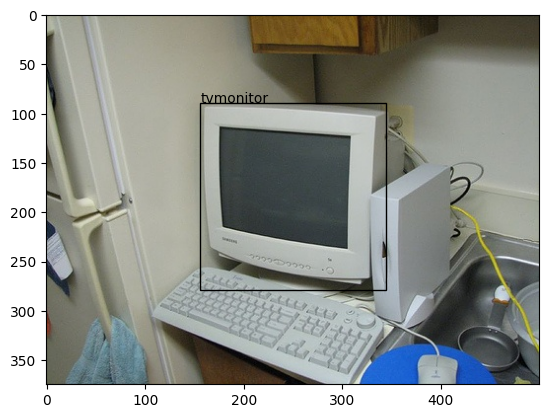

In [7]:
import cv2
import matplotlib.pyplot as plt
import torch
import xml.etree.ElementTree as ET

img_path = "../Data/JPEGImages/2007_000039.jpg"
xml_path = "../Data/Annotations/2007_000039.xml"

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


root = ET.parse(xml_path).getroot()

boxes = []
labels = []

for obj in root.findall("object"):

    label = obj.find("name").text

    box = obj.find("bndbox")

    xmin = int(box.find("xmin").text)
    ymin = int(box.find("ymin").text)
    xmax = int(box.find("xmax").text)
    ymax = int(box.find("ymax").text)

    boxes.append([xmin, ymin, xmax, ymax])
    labels.append(label)

boxes = torch.tensor(boxes)

print("Image shape:", img.shape)
print("Boxes:", boxes)
print("Labels:", labels)

plt.imshow(img)

for box, label in zip(boxes, labels):

    xmin, ymin, xmax, ymax = box

    plt.gca().add_patch(
        plt.Rectangle(
            (xmin, ymin),
            xmax - xmin,
            ymax - ymin,
            fill=False
        )
    )

    plt.text(xmin, ymin, label)

plt.show()